# NB06: (An Introduction to) Semantic Analysis

## Language Processing

## LEI/2025-26

#### Nuno Macedo
Universidade do Minho



# 6.1 Semantic Analysis

- **Semantic analysis** follows the syntactic analysis phase in the language-processing pipeline

- Unlike syntactic analysis, which validates whether the input text is structured correctly, semantic analysis *statically* assigns and validates *meaning* to syntactic structures
  - Are variables declared more than once?
  - Are variables used outside their scope?
  - Are operators applied to expressions with the correct types?
  - Are functions called with the correct number of arguments?
  - ...

- Semantic analysis typically starts from an *abstract syntax tree* (AST) produced during syntactic analysis, and results in an **annotated** (and validated) AST

- Unlike the previous phases, it is generally harder to specify semantics declaratively and automatically generate a validator
  - Nonetheless, formalisms such as *attribute grammars* exist that help assigning meaning to the AST

- Here, we will only briefly explore the issue of semantic validation, in particular semantic errors that can be caught through the use of *symbol tables*

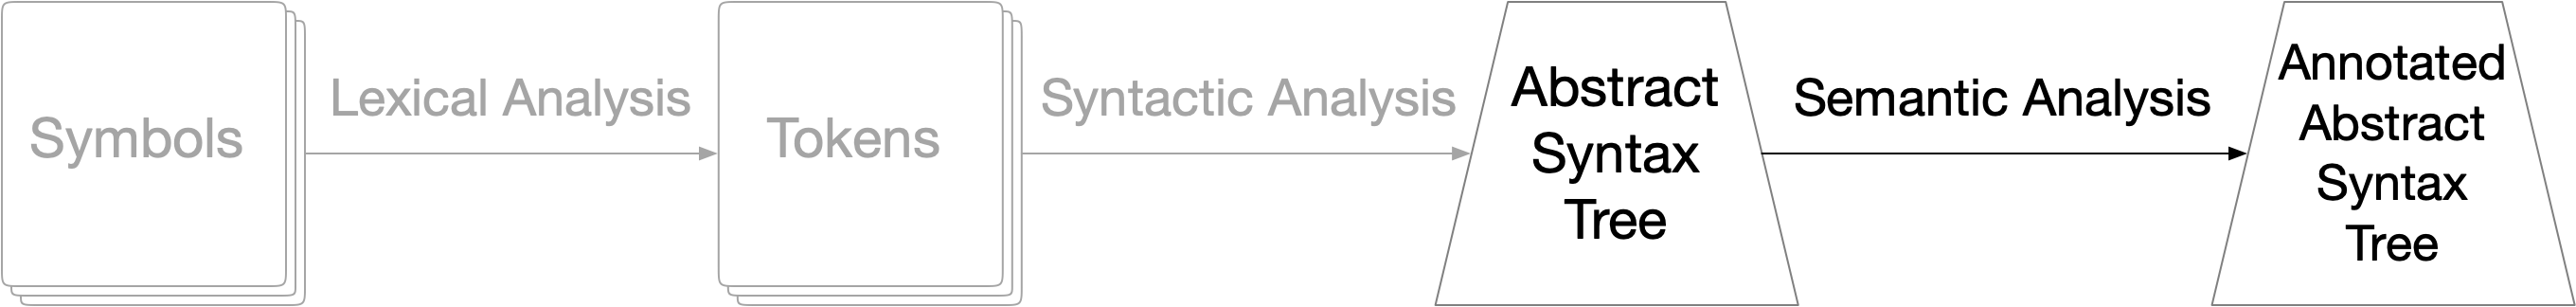

## Static semantic errors

- *Static* semantic errors are semantic errors that can be detected for our input texts at *compile-time*

- These contrast with *dynamic* semantic errors that occur only during program execution (i.e., in *run-time*)

- In language design, there is a tradeoff between what errors are caught statically or dynamically
  - If the compiler is more permissive, the language is more flexible, but more prone to errors in runtime
  - E.g., compare statically-typed languages (such as Haskell) with dynamically-typed ones (such as Python)

📌 Python has very little statically checked semantic errors, most are only caught in run-time. The parsing pipeline is also a bit blur, and all statically detected errors are a `SyntaxError`.

In [ ]:
# lexical error (invalid character)
val = 10€

SyntaxError: invalid character '€' (U+20AC) (1819281980.py, line 2)

In [ ]:
# syntax error (unpaired parenthesis)
val = (10, "€"

In [ ]:
# static semantic error (duplicated identifier)
def fun(x,x): pass

In [ ]:
# run-time semantic error (undeclared variable)
# in languages other than Python, this is often be statically checked
val = "hello" * 2.5

TypeError: can't multiply sequence by non-int of type 'float'

## ✏️ Undeclared variables example: A simple language with assignments

- Let us consider a simple programming language in fully parenthesized prefix notation (S-expressions), specified by the following grammar

- Σ = {`SET`, `PRINT`, `ADD`, `SUB`, `MUL`, `DIV`, `INT`, `ID`, `(`, `)`}
  ```
  Program : Statements
  Statements : Statements Statement
             | Statement
  Statement : Assignment
            | Print
  Assignment : (SET ID Expr)
  Print : (PRINT Expr)
  Expr : (BinIntOp Expr Expr)
       | INT
       | ID
  BinIntOp : ADD | SUB | MUL | DIV
  ```

- There are two kinds of statements:
  - Assign the result of an expression to a variable
  - Print the result of an expression to the output

- To be semantically valid, expressions in this language must only use *declared variables*




In [ ]:
!pip install ply
__file__ = "Untitled.ipynb" # needed to run Ply inside notebook

⚠️ *Note:* since `Ply` relies on reflection, it is not prone to having multiple specifications in the same module
  - This leads to some conflicts when writing specifications in notebooks, which is not recommended
  - Either run the code outside the notebook, restart the notebook session if it becomes corrupted, or run the following functions

In [ ]:
def cleanLexerGlobals():
  "Remove ply.lex identifiers from the global context."
  for t in [n for n in globals() if n.startswith("t_") or n in ("tokens", "literals", "states")]:
    del globals()[t]

def cleanParserGlobals():
  "Remove ply.yacc identifiers from the global context."
  for t in [n for n in globals() if n.startswith("p_")]:
    del globals()[t]
  import os
  try: # avoid conflicts in temp files when running from notebook
    os.remove("parsetab.py")
  except FileNotFoundError:
    pass

In [ ]:
import ply.lex as lex

class LexError(Exception):
    pass

In [ ]:
cleanLexerGlobals()

tokens = ( "SET", "PRINT",
           "INT", "ID",
           "ADD", "SUB", "MUL", "DIV")

literals = "()"

t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"

# rather than defining a rule for each keyword, we use a dictionary to filter keywords caught as IDs
keywords = {
    "set"   : "SET",
    "print" : "PRINT" }

def t_ID(t):
  r"[A-Za-z]\w*"
  # check if lexeme is keyword, if so update token type
  if t.value in keywords:
    t.type = keywords[t.value]
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

In [ ]:
import ply.yacc as yacc

class SyntaxError(Exception):
    pass

In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Assignment
              | Print
    Assignment : "(" SET ID Expr ")"
    Print : "(" PRINT Expr ")"
    Expr : "(" BinIntOp Expr Expr ")"
         | INT
         | ID
    BinIntOp : ADD
             | SUB
             | MUL
             | DIV
    """

def p_error(t):
  # Ply assumes None at end of input, replace it by special token $
  raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    parser.parse(text)
    print("Program is syntactically correct")
  except SyntaxError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
parse("""
(set x 10)
(print (+ x 2))
""")

Program is syntactically correct


In [ ]:
# invalid program, y is not declared!
parse("""
(set x 10)
(print (+ x y))
""")

Program is syntactically correct


- To catch the undeclared variable, we must store its declaration somewhere

- Let's start with simple *symbol table*:
  - a set that registers declared variables


In [ ]:
class SemanticError(Exception):
    pass

In [ ]:
# A simple symbol table, only registers names of identifiers
class SymbolTable():
  def __init__(self):
    self.__table = set()

  # if the variable is not declared, raise a semantic error
  def lookup(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")

  # notice that this allows multiple declarations of the same variable
  def declare(self, id):
    self.__table.add(id)

In [ ]:
cleanParserGlobals()

# our parser is not currenly producing any output, it is only checking syntactic and semantic validity
def p_program(p):
    r"""
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Assignment
              | Print
    """

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    # an assignment to a variable, declare the identifier
    p.parser.symbols.declare(p[3])

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """

def p_expr(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
         | INT
    """

def p_expr_ID(p):
    r"""
    Expr : ID
    """
    # test whether the variable has been declared
    p.parser.symbols.lookup(p[1])

def p_ops(p):
  r"""
  BinIntOp : ADD
           | SUB
           | MUL
           | DIV
  """

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    # initialize an empty symbol table
    parser.symbols = SymbolTable()
    parser.parse(text)
    print("Program is semantically correct")
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
parse("""
(set x 10)
(print (+ x 2))
""")

Program is semantically correct


In [ ]:
parse("""
(set x 10)
(print (+ x y))
""")

Parsing failed: Undeclared variable: y


📌 For simplicity, here we are performing semantic checks during parsing. In a proper language-processing pipeline, this would typically be a separate pass over the AST.

## Symbol tables

- A **symbol table** is a data structure used by compilers to store information about identifiers

- Each entry typically contains:
  - identifier name
  - kind (variable, function, ...)
  - type (if applicable)
  - additional attributes (e.g., initialized, arity, scope level)

- Symbol tables support operations such as:
  - insert / declare
  - lookup
  - (optionally) update

- They are used to detect semantic errors such as:
  - use of undeclared identifiers
  - duplicate declarations
  - use of uninitialized variables
  - incorrect use of functions (e.g., arity)

- They can be implemented as a *dictionary* from identifier to attributes

## ✏️ Uninitialized variables example: A simple language with declarations

- Let's expand the previous language to distinguish between the *declaration* of variables and the *assignment* of values

- Σ = {`DECL`, `SET`, `PRINT`, `ADD`, `SUB`, `MUL`, `DIV`, `INT`, `ID`, `(`, `)`}


  ```
  Program : Statements
  Statements : Statements Statement
             | Statement
  Statement : Declaration
            | Assignment
            | Print
  Declaration : (DECL ID)
  Assignment : (SET ID Expr)
  Print : (PRINT Expr)
  Expr : (BinIntOp Expr Expr)
       | INT
       | ID
  BinIntOp : ADD | SUB | MUL | DIV
  ```


- To be semantically valid, in this language:
  - assignments must only apply to *declared variables*
  - expressions must only use *declared and initialized variables*


In [ ]:
cleanLexerGlobals()

tokens = ("SET", "DECL", "PRINT",
          "INT", "ID",
          "ADD", "SUB", "MUL", "DIV")

literals = "()"

t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"

keywords = {
    "set"   : "SET",
    "decl"  : "DECL",
    "print" : "PRINT" }

def t_ID(t):
  r"[A-Za-z]\w*"
  if t.value in keywords:
    t.type = keywords[t.value]
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

In [ ]:
# A simple symbol table, but now also registers whether the variable has been initialized
class SymbolTable():
  def __init__(self):
    self.__table = {}

  # return whether initialized, but only if declared
  def lookup(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")
    else:
      return self.__table.get(id)

  # since declaration and assignment are separated, do not allow duplicate declarations
  def declare(self, id):
    if id in self.__table:
      raise SemanticError(f"Duplicate declaration: {id}")
    self.__table[id] = False

  # mark a variable as initialized, but only if declared
  def initialize(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")
    self.__table[id] = True

In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Assignment
              | Declaration
              | Print
    """

def p_decl(p):
    r"""
    Declaration : "(" DECL ID ")"
    """
    # a variable declaration, declare the identifier
    p.parser.symbols.declare(p[3])

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    # mark variable as initialized
    p.parser.symbols.initialize(p[3])

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """

def p_expr(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
         | INT
    """

def p_expr_ID(p):
    r"""
    Expr : ID
    """
    # test whether the variable has been declared and initialized
    if not p.parser.symbols.lookup(p[1]):
        raise SemanticError(f"Uninitialized variable: {p[1]}")

def p_ops(p):
  r"""
  BinIntOp : ADD
           | SUB
           | MUL
           | DIV
  """

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    # initialize an empty symbol table
    parser.symbols = SymbolTable()
    parser.parse(text)
    print("Program is semantically correct")
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
parse("""
(decl x)
(set x 10)
(print (+ x 2))
""")

Program is semantically correct


In [ ]:
parse("""
(set x 10)
(print (+ x 2))
""")

Parsing failed: Undeclared variable: x


In [ ]:
parse("""
(decl x)
(print (+ x 2))
""")

Parsing failed: Uninitialized variable: x


In [ ]:
parse("""
(decl x)
(decl x)
(set x 10)
(print (+ x 2))
""")

Parsing failed: Duplicate declaration: x


## (Basic) Type checking

- So far, we have verified that:
  - variables are declared
  - variables are initialized before use

- We now extend semantic analysis to verify that expressions are used correctly by checking whether the expressions are *correctly typed*

- Static type systems are a central component of many programming languages

- Semantic analysis computes the *type* of each expression and validates it

- Each expression has a type, and each operator imposes specific constraints on these types

- Here we will implement a very simple type checker:
  - Each production checks the types of its sub-expressions and returns its type
  - Leaves have a fixed type:
    - literals have intrinsic types
    - identifiers obtain their type from the symbol table
  - This effectively annotates the AST with type information

- In contrast, modern type systems go much further, supporting features such as:
  - type inference (automatically deducing types)
  - polymorphism (generics, type classes/traits)
  - subtyping and variance
  - ...




## ✏️ Type checking example: A simple language with types

- Consider now that we introduce a new value type in our language: Booleans

- Σ = {`SET`, `PRINT`, `ADD`, `SUB`, `MUL`, `DIV`, `AND`, `OR`, `LT`, `GT`,`EQ`, `INT`, `TRUE`, `FALSE`, `ID`, `INTKW`, `BOOLKW`, `(`, `)`}

  ```
  Program : Statements
  Statements : Statements Statement
             | Statement
  Statement : Declaration
            | Assignment
            | Print
  Declaration : (DECL ID Type)
  Assignment : (SET ID Expr)
  Print : (PRINT Expr)
  Expr : (BinIntOp Expr Expr)
       | (BinBoolOp Expr Expr)
       | (BinCompOp Expr Expr)
       | INT
       | TRUE
       | FALSE
       | ID
  BinIntOp : ADD | SUB | MUL | DIV
  BinBoolOp : AND | OR
  BinCompOp : LT | GT | EQ
  Type : INTKW
       | BOOLKW
  ```

- We want to type check expressions:
  - Arithmetic operations can only be applied to numbers, and return numbers
  - Comparison operations can only be applied to numbers, and return Booleans
  - Logic operations can only be applied to Booleans, and return Booleans

- Variables must be assigned a type during declaration



In [ ]:
cleanLexerGlobals()

tokens = ("DECL", "SET", "PRINT",
          "INT", "ID", "TRUE", "FALSE",
          "OR", "AND", "ADD", "SUB", "MUL", "DIV", "LT", "GT", "EQ",
          "INTKW", "BOOLKW")

literals = "()"

t_AND = r"&&"
t_OR = r"\|\|"
t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"
t_LT = r"<"
t_GT = r">"
t_EQ = r"="

keywords = {
    "true"  : "TRUE",
    "false" : "FALSE",
    "decl"  : "DECL",
    "set"   : "SET",
    "print" : "PRINT",
    "int"   : "INTKW",
    "bool"  : "BOOLKW" }

def t_ID(t):
  r"[A-Za-z]\w*"
  if t.value in keywords:
    t.type = keywords[t.value]
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

In [ ]:
# A simple symbol table, but now registers whether the variable has been initialized and its type
class SymbolTable():
  def __init__(self):
    self.__table = {}

  # return whether initialized and its type, but only if declared
  def lookup(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")
    else:
      return self.__table.get(id)

  # declare an identifier and its type
  # since declaration and assignment are separated, do not allow duplicate declarations
  def declare(self, id, tpe):
    if id in self.__table:
      raise SemanticError(f"Duplicate declaration: {id}")
    self.__table[id] = (tpe, False)

  # mark a variable as initialized, but only if declared
  def initialize(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")
    self.__table[id] = (self.__table[id][0], True)

In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Assignment
              | Declaration
              | Print
    """

def p_decl(p):
    r"""
    Declaration : "(" DECL ID Type ")"
    """
    # a variable declaration, declare the identifier
    p.parser.symbols.declare(p[3], p[4])

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    # check whether the declared type is the same as the expression
    tpe, ini = p.parser.symbols.lookup(p[3])
    if tpe == p[4]:
      # mark variable as initialized
      p.parser.symbols.initialize(p[3])
    else:
      raise SemanticError(f"Type error: expected {tpe}, got {p[4]}")

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """

def p_expr_int(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
         | INT
    """
    # propagate the expression type upwards (int)
    if len(p) == 2:
      p[0] = "int"
    # check whether the left sub-expression has correct type (int)
    elif p[3] != "int":
      raise SemanticError(f"Type error: expected int, got {p[3]}")
    # check whether the right sub-expression has correct type (int)
    elif p[4] != "int":
      raise SemanticError(f"Type error: expected int, got {p[4]}")
    # propagate the expression type upwards (int)
    else:
      p[0] = "int"

def p_expr_bool(p):
    r"""
    Expr : "(" BinBoolOp Expr Expr ")"
         | TRUE
         | FALSE
    """
    # propagate the expression type upwards (bool)
    if len(p) == 2:
      p[0] = "bool"
    # check whether the left sub-expression has correct type (bool)
    elif p[3] != "bool":
      raise SemanticError(f"Type error: expected bool, got {p[3]}")
    # check whether the left sub-expression has correct type (bool)
    elif p[4] != "bool":
      raise SemanticError(f"Type error: expected bool, got {p[4]}")
    # propagate the expression type upwards (bool)
    else:
      p[0] = "bool"

def p_expr_comp(p):
    r"""
    Expr : "(" BinCompOp Expr Expr ")"
    """
    # check whether the left sub-expression has correct type (int)
    if p[3] != "int":
      raise SemanticError(f"Type error: expected int, got {p[3]}")
    # check whether the left sub-expression has correct type (int)
    elif p[4] != "int":
      raise SemanticError(f"Type error: expected int, got {p[4]}")
    # propagate the expression type upwards (bool)
    else:
      p[0] = "bool"

def p_expr_ID(p):
    r"""
    Expr : ID
    """
    # test whether the variable has been declared and initialized
    tpe, ini = p.parser.symbols.lookup(p[1])
    if not ini:
        raise SemanticError(f"Uninitialized variable: {p[1]}")
    # propagate the identifier type upwards
    p[0] = tpe

def p_ops(p):
  r"""
  BinIntOp : ADD
           | SUB
           | MUL
           | DIV
  BinBoolOp : AND
            | OR
  BinCompOp : LT
            | GT
            | EQ
  """

def p_type(p):
  r"""
  Type : INTKW
       | BOOLKW
  """
  p[0] = p[1]

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    # initialize an empty symbol table
    parser.symbols = SymbolTable()
    parser.parse(text)
    print("Program is semantically correct")
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
parse("""
(decl x int)
(set x 10)
(print (+ x 2))
""")

Program is semantically correct


In [ ]:
parse("""
(decl x bool)
(set x 10)
(print (+ x 2))
""")

Parsing failed: Type error: expected bool, got int


In [ ]:
parse("""
(decl x bool)
(set x true)
(print (+ x 2))
""")

Parsing failed: Type error: expected int, got bool


In [ ]:
parse("""
(decl x int)
(set x 10)
(print (|| (< x 0) (> x 0)))
""")

Program is semantically correct


In [ ]:
parse("""
(decl x int)
(set x 10)
(print (+ (< x 0) (> x 0)))
""")

Parsing failed: Type error: expected int, got bool


## Functions

- So far, our programs consisted of variable declarations and expressions

- We now introduce **functions** to:
  - structure programs
  - reuse computations

- Functions introduce new semantic constraints:
  - functions must be declared before use
  - function calls must provide the correct number of arguments
  - the type of the arguments and the return value must be type checked

## Symbol tables with functions

- The symbol table must now also store information about functions

- For each function, we store:
  - its name
  - its kind (function, in contrast to variable)
  - its arity (number of parameters)

- During semantic analysis:
  - function declarations are inserted into the symbol table
  - function calls are checked against the stored information


## Nested scopes

- Identifiers are only visible within a certain region of the program (their *scope*)

- Functions introduce a new scope:
  - parameters are local to the function
  - identifiers declared inside the function are not visible outside

- To support this, the symbol table is extended to a *stack of tables*:
  - one table per scope
  - the current scope is the top of the stack

- When entering a function:
  - push a new table onto the stack
  - insert the parameters into this table

- When leaving the function:
  - pop the table from the stack

- Identifier lookup searches from the top of the stack downwards
  - gives priority to the deepest scope

## ✏️ Function example: A simple language with functions

- Let us allow the definition of auxiliary functions in our language for integer expressions
  - These will be simple expressions with parameters
  - No further variables declared inside functions

- Σ = {`SET`, `FUN`, `PRINT`, `ADD`, `SUB`, `MUL`, `DIV`, `INT`, `ID`, `(`, `)`}

  ```
  Program : Statements
  Statements : Statements Statement
             | Statement
  Statement : VarDeclaration
            | FunDeclaration
            | Assignment
            | Print
  VarDeclaration : (DECL ID)
  FunDeclaration : (FUN ID (Parameters) Expr)
  Assignment : (SET ID Expr)
  Print : (PRINT Expr)
  Expr : (BinIntOp Expr Expr)
       | (ID Arguments)
       | INT
       | ID
  BinIntOp : ADD | SUB | MUL | DIV
  Parameters : Parameters ID
             |
  Arguments : Arguments Expr
            |
  ```

- This will require additional semantic checks:
  - When a function is called, it must have the appropriate number of arguments
  - Parameters are only accessible inside the function body
  - The global context is still accessible in the function body





- We face a problem when creating the nested scopes:
  - `Ply.yacc` is an LR parser, and semantic actions are only applied at reduce steps

- So, the action for production `(FUN ID (Parameters) Expr)`, is only applied after `Expr` has already been created
  - If we push a new table into the stack at production `(FUN ID (Parameters) Expr)`, it will not be accessible to `Expr`

- However, we also know that the shift-reduce is applied from left to right, so sub-expressions to the left of `Expr` will be reduced before it
  - We can explore this to push the new symbol table into the stack before `Expr` is processed

In [ ]:
cleanLexerGlobals()

tokens = ("DECL", "SET", "FUN", "PRINT",
          "INT", "ID",
          "ADD", "SUB", "MUL", "DIV")

literals = "()"

t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"

keywords = {
    "decl"  : "DECL",
    "fun"   : "FUN",
    "set"   : "SET",
    "print" : "PRINT" }

def t_ID(t):
  r"[A-Za-z]\w*"
  if t.value in keywords:
    t.type = keywords[t.value]
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

In [ ]:
# A symbol table that registers identifiers, their kind (variable or function), and further attributes
class SymbolTable():
  def __init__(self):
    self.__table = [{}]

  # push a new scope into the stack
  def push(self):
    self.__table.append({})

  # pop the most recent scope from the stack
  def pop(self):
    self.__table.pop()

  # return whether variable initialized, but only if declared
  def lookup_var(self, id):
    # search all the scopes, starting with the most recent one
    for table in self.__table[::-1]:
      if id in table:
        if table.get(id)[0] != "var":
          raise SemanticError(f"Identifier is not a variable: {id}")
        return table.get(id)[1]
    raise SemanticError(f"Undeclared variable: {id}")

  # return the arity of a function, but only if declared
  def lookup_fun(self, id):
    # search all the scopes, starting with the most recent one
    for table in self.__table[::-1]:
      if id in table:
        if table.get(id)[0] != "fun":
          raise SemanticError(f"Identifier is not a function: {id}")
        return table.get(id)[1]
    raise SemanticError(f"Undeclared variable: {id}")

  # declare a variable
  def declare_var(self, id):
    if id in self.__table[-1]:
      raise SemanticError(f"Duplicate declaration: {id}")
    self.__table[-1][id] = ("var", False)

  # declare a function
  def declare_fun(self, id, params):
    if id in self.__table[-1]:
      raise SemanticError(f"Duplicate declaration: {id}")
    self.__table[-1][id] = ("fun", params)

  # mark a variable as initialized, but only if declared
  def initialize(self, id):
    for table in self.__table[::-1]:
      if id in table:
        if table.get(id)[0] != "var":
          raise SemanticError(f"Identifier is not a variable: {id}")
        table[id] = ("var", True)
        return
    raise SemanticError(f"Undeclared variable: {id}")

In [ ]:
cleanParserGlobals()

def p_program(p):
    r"""
    Program : Statements
    Statements : Statements Statement
               | Statement
    Statement : Assignment
              | VarDeclaration
              | FunDeclaration
              | Print
    """

def p_decl(p):
    r"""
    VarDeclaration : "(" DECL ID ")"
    """
    # declare the variable
    p.parser.symbols.declare_var(p[3])

# will only be applied after Parameters and Expr are built, by the local context must created before
def p_fun(p):
    r"""
    FunDeclaration : "(" fun ID "(" Parameters ")" Expr ")"
    """
    # declare the variable
    p.parser.symbols.pop()
    p.parser.symbols.declare_fun(p[3], p[5])

# a "dummy" production that allows the creation of the function context
def p_fun_aux(p):
    r"""
    fun : FUN
    """
    p.parser.symbols.push()

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    # mark variable as initialized
    p.parser.symbols.initialize(p[3])

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """

def p_expr(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
         | INT
    """

def p_expr_call(p):
    r"""
    Expr : "(" ID Arguments ")"
    """
    if p.parser.symbols.lookup_fun(p[2]) != p[3]:
        raise SemanticError(f"Invalid number of arguments: {p[3]}")

def p_expr_ID(p):
    r"""
    Expr : ID
    """
    # test if declared and initialized in symbol table
    if not p.parser.symbols.lookup_var(p[1]):
        raise SemanticError(f"Uninitialized variable: {p[1]}")

def p_ops(p):
  r"""
  BinIntOp : ADD
           | SUB
           | MUL
           | DIV
  """

def p_params(p):
  r"""
  Parameters : Parameters ID
             |
  """
  if len(p) > 1:
    p.parser.symbols.declare_var(p[2])
    p.parser.symbols.initialize(p[2])
    p[0] = 1 + p[1]
  else:
    p[0] = 0

def p_args(p):
  r"""
  Arguments : Arguments Expr
            |
  """
  if len(p) > 1:
    p[0] = 1 + p[1]
  else:
    p[0] = 0

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    # initialize an empty symbol table
    parser.symbols = SymbolTable()
    parser.parse(text)
    print("Program is semantically correct")
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
parse("""
(fun double (x) (* x 2))
(print (double 10))
""")

Program is semantically correct


In [ ]:
parse("""
(fun mult (x y) (* x y))
(print (double 10))
""")

Parsing failed: Undeclared variable: double


In [ ]:
parse("""
(fun mult (x y) (* x y))
(print (mult 10))
""")

Parsing failed: Invalid number of arguments: 1


In [ ]:
parse("""
(fun mult (x y) (* x y))
(print (mult 10 20))
""")

Program is semantically correct


In [ ]:
parse("""
(fun mult (x y) (* x y))
(print (mult 10 x))
""")

Parsing failed: Undeclared variable: x


# 6.2 Annotated ASTs

- Semantic analysis does not only detect errors

- It also enriches the syntax tree with additional information

- Examples of annotations:
  - type of expressions
  - symbol information (e.g., variable declarations)

- The annotated AST is useful in later stages of the language processing pipeline (e.g., code generation)

## ✏️ Annotated AST example: A simple language with types

- Recall the version of the language with integer and Boolean types

- Σ = {`SET`, `PRINT`, `ADD`, `SUB`, `MUL`, `DIV`, `AND`, `OR`, `LT`, `GT`,`EQ`, `INT`, `TRUE`, `FALSE`, `ID`, `INTKW`, `BOOLKW`, `(`, `)`}

  ```
  Program : Statements
  Statements : Statements Statement
             | Statement
  Statement : Declaration
            | Assignment
            | Print
  Declaration : (DECL ID Type)
  Assignment : (SET ID Expr)
  Print : (PRINT Expr)
  Expr : (BinIntOp Expr Expr)
       | (BinBoolOp Expr Expr)
       | (BinCompOp Expr Expr)
       | INT
       | TRUE
       | FALSE
       | ID
  BinIntOp : ADD | SUB | MUL | DIV
  BinBoolOp : AND | OR
  BinCompOp : LT | GT | EQ
  Type : INTKW
       | BOOLKW
  ```

- Let us generate an annotated AST as a nested tuple where:
  - expressions have the shape `(kind, type, children)`
  - statements have the shape `(kind, children)`
  

In [ ]:
cleanLexerGlobals()

tokens = ("DECL", "SET", "PRINT",
          "INT", "ID", "TRUE", "FALSE",
          "OR", "AND", "ADD", "SUB", "MUL", "DIV", "LT", "GT", "EQ",
          "INTKW", "BOOLKW")

literals = "()"

t_AND = r"&&"
t_OR = r"\|\|"
t_ADD = r"\+"
t_SUB = r"-"
t_MUL = r"\*"
t_DIV = r"/"
t_LT = r"<"
t_GT = r">"
t_EQ = r"="

keywords = {
    "true"  : "TRUE",
    "false" : "FALSE",
    "decl"  : "DECL",
    "set"   : "SET",
    "print" : "PRINT",
    "int"   : "INTKW",
    "bool"  : "BOOLKW" }

def t_ID(t):
  r"[A-Za-z]\w*"
  if t.value in keywords:
    t.type = keywords[t.value]
  return t

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

In [ ]:
# A simple symbol table, but now registers whether the variable has been initialized and its type
class SymbolTable():
  def __init__(self):
    self.__table = {}

  # return whether initialized and its type, but only if declared
  def lookup(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")
    else:
      return self.__table.get(id)

  # declare an identifier and its type
  # since declaration and assignment are separated, do not allow duplicate declarations
  def declare(self, id, tpe):
    if id in self.__table:
      raise SemanticError(f"Duplicate declaration: {id}")
    self.__table[id] = (tpe, False)

  # mark a variable as initialized, but only if declared
  def initialize(self, id):
    if id not in self.__table:
      raise SemanticError(f"Undeclared variable: {id}")
    self.__table[id] = (self.__table[id][0], True)

In [ ]:
cleanParserGlobals()

import ply.yacc as yacc

def p_program(p):
    r"""
    Program : Statements
    """
    p[0] = ("program", p[1])

def p_statements(p):
    r"""
    Statements : Statements Statement
               | Statement
    """
    if len(p) == 2:
      p[0] = (p[1],)
    else:
      p[0] = p[1] + (p[2],)

def p_statement(p):
    r"""
    Statement : Assignment
              | Declaration
              | Print
    """
    p[0] = p[1]

def p_decl(p):
    r"""
    Declaration : "(" DECL ID Type ")"
    """
    # declare the variable
    p.parser.symbols.declare(p[3], p[4])
    p[0] = ("decl", p[3], p[4])

def p_assign(p):
    r"""
    Assignment : "(" SET ID Expr ")"
    """
    # check whether the declared type is the same as the expression
    tpe, ini = p.parser.symbols.lookup(p[3])
    if tpe == p[4][1]:
      # mark variable as initialized
      p.parser.symbols.initialize(p[3])
    else:
      raise SemanticError(f"Type error: expected {tpe}, got {p[4][1]}")
    p[0] = ("set", p[3], p[4])

def p_print(p):
    r"""
    Print : "(" PRINT Expr ")"
    """
    p[0] = ("print", p[3])

def p_expr_int(p):
    r"""
    Expr : "(" BinIntOp Expr Expr ")"
         | INT
    """
    # propagate the expression type upwards (int)
    if len(p) == 2:
      p[0] = (p[1], "int")
    # check whether the left sub-expression has correct type (int)
    elif p[3][1] != "int":
      raise SemanticError(f"Type error: expected int, got {p[3][1]}")
    # check whether the right sub-expression has correct type (int)
    elif p[4][1] != "int":
      raise SemanticError(f"Type error: expected int, got {p[4][1]}")
    # propagate the expression type upwards (int)
    else:
      p[0] = (p[2], "int", (p[3], p[4]))

def p_expr_bool(p):
    r"""
    Expr : "(" BinBoolOp Expr Expr ")"
         | TRUE
         | FALSE
    """
    # propagate the expression type upwards (bool)
    if len(p) == 2:
      p[0] = (p[1], "bool")
    # check whether the left sub-expression has correct type (bool)
    elif p[3][1] != "bool":
      raise SemanticError(f"Type error: expected bool, got {p[3][1]}")
    # check whether the left sub-expression has correct type (bool)
    elif p[4][1] != "bool":
      raise SemanticError(f"Type error: expected bool, got {p[4][1]}")
    # propagate the expression type upwards (bool)
    else:
      p[0] = (p[2], "bool", (p[3], p[4]))

def p_expr_comp(p):
    r"""
    Expr : "(" BinCompOp Expr Expr ")"
    """
    # check whether the left sub-expression has correct type (int)
    if p[3][1] != "int":
      raise SemanticError(f"Type error: expected int, got {p[3][1]}")
    # check whether the left sub-expression has correct type (int)
    elif p[4][1] != "int":
      raise SemanticError(f"Type error: expected int, got {p[4][1]}")
    # propagate the expression type upwards (bool)
    else:
      p[0] = (p[2], "bool", (p[3], p[4]))

def p_expr_ID(p):
    r"""
    Expr : ID
    """
    # test whether the variable has been declared and initialized
    tpe, ini = p.parser.symbols.lookup(p[1])
    if not ini:
        raise SemanticError(f"Uninitialized variable: {p[1]}")
    # propagate the identifier type upwards
    p[0] = (p[1], p.parser.symbols.lookup(p[1])[0])

def p_ops(p):
  r"""
  BinIntOp : ADD
           | SUB
           | MUL
           | DIV
  BinBoolOp : AND
            | OR
  BinCompOp : LT
            | GT
            | EQ
  """
  p[0] = p[1]

def p_type(p):
  r"""
  Type : INTKW
       | BOOLKW
  """
  p[0] = p[1]

class SemanticError(Exception):
    pass

class SyntaxError(Exception):
    pass

def p_error(t):
    raise SyntaxError(f"Unexpected token: {t.type if t else '$'}")

parser = yacc.yacc(write_tables=False) # avoid conflicts in notebook

def parse(text):
  try:
    # initialize an empty symbol table
    parser.symbols = SymbolTable()
    ast = parser.parse(text)
    print("Program is semantically correct")
    return ast
  except SyntaxError as e:
    print("Parsing failed:", e)
  except SemanticError as e:
    print("Parsing failed:", e)

Generating LALR tables


In [ ]:
parse("""
(print (+ 10 20))
""")

Program is semantically correct


('program', (('print', ('+', 'int', ((10, 'int'), (20, 'int')))),))

In [ ]:
parse("""
(print (|| (< 10 0) (> 20 0)))
""")

Program is semantically correct


('program',
 (('print',
   ('||',
    'bool',
    (('<', 'bool', ((10, 'int'), (0, 'int'))),
     ('>', 'bool', ((20, 'int'), (0, 'int')))))),))

In [ ]:
parse("""
(decl x int)
(print (|| (< x 0) (> x 0)))
""")

Parsing failed: Uninitialized variable: x


In [ ]:
parse("""
(decl x int)
(set x 10)
(print (|| (< x 0) (> x 0)))
""")

Program is semantically correct


('program',
 (('decl', 'x', 'int'),
  ('set', 'x', (10, 'int')),
  ('print',
   ('||',
    'bool',
    (('<', 'bool', (('x', 'int'), (0, 'int'))),
     ('>', 'bool', (('x', 'int'), (0, 'int'))))))))

-- Nuno Macedo, 2026-04-28